In [1]:
print("Installing dependencies for OCR Pipeline...")
!apt-get update

# Install the Tesseract engine, Poppler for PDFs, and the C++ build tools
!apt-get install -y tesseract-ocr poppler-utils build-essential

!pip install -q pytesseract pdf2image opencv-python-headless rank_bm25

# For the ColQwen Pipeline (Pipeline B)
print("\nInstalling dependencies for ColQwen Pipeline...")
!pip install -q --upgrade transformers accelerate bitsandbytes sentencepiece
# FIX: Install the custom model engine
!pip install -q colpali-engine

print("\n✅ All dependencies installed.")

Installing dependencies for OCR Pipeline...
Get:1 http://deb.debian.org/debian bookworm InRelease [151 kB]
Get:2 http://deb.debian.org/debian bookworm-updates InRelease [55.4 kB]
Get:3 http://deb.debian.org/debian-security bookworm-security InRelease [48.0 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/debian12/x86_64  InRelease [1581 B]
Get:5 http://deb.debian.org/debian bookworm/main amd64 Packages [8791 kB]
Get:6 http://deb.debian.org/debian-security bookworm-security/main amd64 Packages [284 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/debian12/x86_64  Packages [1012 kB]
Fetched 10.3 MB in 2s (5302 kB/s)

N: Repository 'http://deb.debian.org/debian bookworm InRelease' changed its 'Version' value from '12.11' to '12.12'



build-essential is already the newest version (12.9).
The following additional packages will be installed:
  libgif7 liblept5 libnspr4 libnss3 libpoppler126 libtesseract5 poppler-data tesseract-ocr-eng
  tesseract-ocr-osd


In [10]:
### Cell 2: Build and Index Pipeline A (Your OCR Script + BM25 Search)
# --- 2. BUILD AND INDEX PIPELINE A (OCR + BM25) ---

import os
from slide_processor import SlideOCR
from rank_bm25 import BM25Okapi
import time

print("--- Building Pipeline A: Your OCR Script + BM25 Search ---")

# --- Part 1: Run your script to extract text ---
# This uses your file exactly as provided.
# SLIDE_DIR = "slides"
SLIDE_DIR = "/root"
OCR_OUTPUT_DIR = "results/ocr"

print(f"Running OCR extraction on all PDFs in '{SLIDE_DIR}'...")
ocr_processor = SlideOCR(output_dir=OCR_OUTPUT_DIR)
ocr_results = ocr_processor.process_slide_directory(SLIDE_DIR)
print(f"\nOCR extraction complete. Processed {len(ocr_results)} pages.")

# --- Part 2: Build the Search Index (the missing retrieval part) ---
# Your script extracts text; BM25 makes it searchable.
corpus = []
doc_metadata = []
for result in ocr_results:
    corpus.append(result['text'])
    doc_metadata.append({'source': os.path.basename(result['source']), 'page': result['page']})

if not corpus:
    print("Error: No text was extracted. Cannot build search index for Pipeline A.")
    bm25 = None
else:
    tokenized_corpus = [doc.split(" ") for doc in corpus]
    print("\nBuilding BM25 search index...")
    start_time = time.time()
    bm25 = BM25Okapi(tokenized_corpus)
    end_time = time.time()
    print(f"✅ BM25 index built in {end_time - start_time:.2f} seconds.")

# --- Part 3: Create a search function for this pipeline ---
def search_ocr_pipeline(query, top_k=3):
    if bm25 is None:
        print("BM25 index not available.")
        return []
    tokenized_query = query.split(" ")
    doc_scores = bm25.get_scores(tokenized_query)
    
    # Get top k results where score is > 0
    top_n_indices = [i for i in doc_scores.argsort()[-top_k:][::-1] if doc_scores[i] > 0]
    
    results = []
    for i in top_n_indices:
        results.append({
            'score': doc_scores[i],
            'source': doc_metadata[i]['source'],
            'page': doc_metadata[i]['page'],
            'text_snippet': corpus[i][:250] + "..."
        })
    return results

--- Building Pipeline A: Your OCR Script + BM25 Search ---
Running OCR extraction on all PDFs in '/root'...
Using pytesseract for OCR

Processing: Chap_0_Introduction.pdf


Processing slides: 100%|█████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.44s/it]


  - Processed 13 pages
  - Output directory: results/ocr/Chap_0_Introduction

Processing: Chap4_AI_Minimax.pdf


Processing slides: 100%|█████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.38s/it]


  - Processed 32 pages
  - Output directory: results/ocr/Chap4_AI_Minimax

Processing: Chap_5_3D_Graphics.pdf


...

  - Processed 23 pages
  - Output directory: results/ocr/Chap_3_AI

Processing: Chap_1_Math_Physic.pdf


Processing slides: 100%|█████████████████████████████████████████████████████████| 1/1 [00:30<00:00, 30.64s/it]


  - Processed 49 pages
  - Output directory: results/ocr/Chap_1_Math_Physic

Processing: Chap_2_2D_Graphics.pdf


Processing slides: 100%|█████████████████████████████████████████████████████████| 1/1 [00:17<00:00, 17.58s/it]

  - Processed 20 pages
  - Output directory: results/ocr/Chap_2_2D_Graphics

OCR extraction complete. Processed 177 pages.

Building BM25 search index...
✅ BM25 index built in 0.00 seconds.


In [ ]:
del bm25
del corpus
del tokenized_corpus
del doc_metadata

In [8]:
# --- 3. BUILD AND INDEX PIPELINE B (ColQwen) ---

import torch
from PIL import Image
# FIX: Import the custom model and processor classes directly
from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor
from pdf2image import convert_from_path
from pathlib import Path
import time

print("\n--- Building Pipeline B: ColQwen Visual Retrieval ---")

# --- Part 1: Load the ColQwen model ---
print("Loading ColQwen model...")
device = "cuda" if torch.cuda.is_available() else "cpu"

# FIX: Use the specific processor and model classes
processor = ColQwen2_5_Processor.from_pretrained('vidore/colqwen2.5-v0.2')
model = ColQwen2_5.from_pretrained(
    'vidore/colqwen2.5-v0.2', 
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map=device,
).eval()
print("✅ ColQwen model loaded.")

# --- Part 2: Build the Search Index ---
# For ColQwen, "indexing" means creating patch embeddings for each slide image.
colqwen_index = []
colqwen_images = {} # To store images for display

print(f"\nIndexing all PDFs in '{SLIDE_DIR}' with ColQwen...")
start_time = time.time()
slide_files = list(Path(SLIDE_DIR).glob('*.pdf'))

for pdf_path in slide_files:
    print(f"  - Processing {pdf_path.name}...")
    images = convert_from_path(str(pdf_path))
    for i, page_image in enumerate(images):
        # FIX: Correct encoding logic (process image, then pass to model)
        image_inputs = processor.process_images([page_image]).to(model.device)
        with torch.no_grad():
            doc_outputs = model(**image_inputs)

        colqwen_index.append({
            'source': pdf_path.name,
            'page': i + 1,
            # Embeddings are directly the model output
            'embeddings': doc_outputs
        })
        colqwen_images[f"{pdf_path.name}_{i+1}"] = page_image

end_time = time.time()
print(f"✅ ColQwen index built for {len(colqwen_index)} pages in {end_time - start_time:.2f} seconds.")

# --- Part 3: Create a search function for this pipeline ---\n
def search_colqwen_pipeline(query, top_k=3):
    # FIX: Correct query encoding logic (process query, then pass to model)
    query_inputs = processor.process_queries([query]).to(model.device)
    with torch.no_grad():
        query_embeds = model(**query_inputs)
    
    page_scores = []
    for doc in colqwen_index:
        doc_embeds = doc['embeddings']
        
        # FIX: Use the special scoring function for ColBERT-style multi-vector embeddings
        score = processor.score_multi_vector(query_embeds, doc_embeds).item()
        page_scores.append(score)
    
    top_n_indices = sorted(range(len(page_scores)), key=lambda i: page_scores[i], reverse=True)[:top_k]
    
    results = []
    for i in top_n_indices:
        doc_info = colqwen_index[i]
        results.append({
            'score': page_scores[i],
            'source': doc_info['source'],
            'page': doc_info['page'],
            'image': colqwen_images[f"{doc_info['source']}_{doc_info['page']}"]
        })
    return results


--- Building Pipeline B: ColQwen Visual Retrieval ---
Loading ColQwen model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ ColQwen model loaded.

Indexing all PDFs in '/root' with ColQwen...
  - Processing Chap_0_Introduction.pdf...
  - Processing Chap4_AI_Minimax.pdf...
  - Processing Chap_5_3D_Graphics.pdf...
  - Processing Chap_4_Network.pdf...
  - Processing Chap_3_AI.pdf...
  - Processing Chap_1_Math_Physic.pdf...
  - Processing Chap_2_2D_Graphics.pdf...
✅ ColQwen index built for 177 pages in 125.74 seconds.


In [9]:
# --- New Cell: Save ColQwen Index to Disk ---
import pickle
import os
from pathlib import Path

# Create a directory to store the saved index
SAVE_DIR = "results/colqwen_index"
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

# 1. Save the embeddings (colqwen_index)
index_path = os.path.join(SAVE_DIR, 'colqwen_index.pkl')
with open(index_path, 'wb') as f:
    pickle.dump(colqwen_index, f)
print(f"✅ ColQwen Embeddings Index saved to: {index_path}")

# 2. Save the images dictionary (colqwen_images)
# Note: Saving PIL images is large, but necessary for evaluation display.
images_path = os.path.join(SAVE_DIR, 'colqwen_images.pkl')
with open(images_path, 'wb') as f:
    pickle.dump(colqwen_images, f)
print(f"✅ ColQwen Image Dictionary saved to: {images_path}")

# Delete the large model and processor after saving the index
del model
del processor
print("\n🧹 Deleted large model and processor objects.")

✅ ColQwen Embeddings Index saved to: results/colqwen_index/colqwen_index.pkl
✅ ColQwen Image Dictionary saved to: results/colqwen_index/colqwen_images.pkl

🧹 Deleted large model and processor objects.


PERFORMING QUERY: 'What is the plane equation used in game physics?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 7.13)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_1_Math_Physic.pdf, Page: 25 (Score: 15.3125)


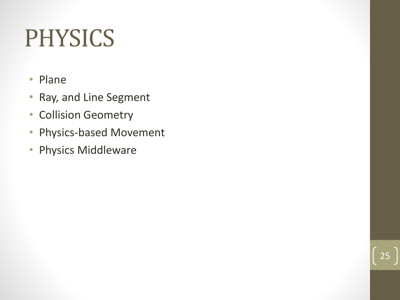

  Source: Chap_1_Math_Physic.pdf, Page: 49 (Score: 15.1250)


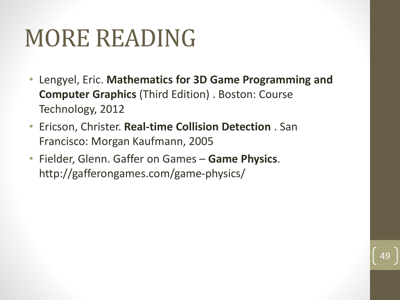

  Source: Chap_1_Math_Physic.pdf, Page: 26 (Score: 14.6875)


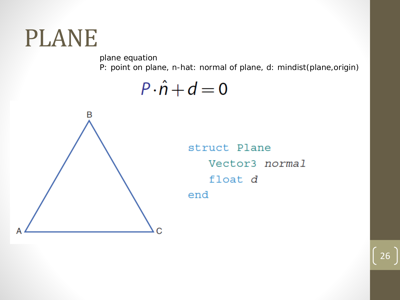




PERFORMING QUERY: 'What is the difference between AABB and bounding sphere collision detection?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 10 (Score: 7.90)
  Snippet: DOT PRODUCT

(a) (b)

Angle between unit vectors (a), and scalar projection (b)....

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_1_Math_Physic.pdf, Page: 34 (Score: 18.5000)


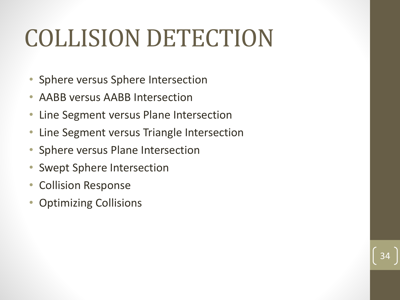

  Source: Chap_1_Math_Physic.pdf, Page: 30 (Score: 18.2500)


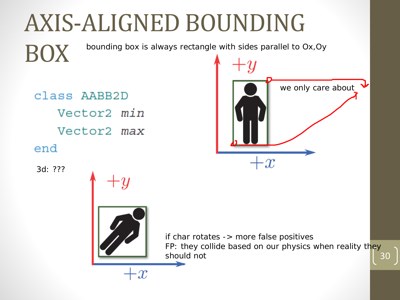

  Source: Chap_1_Math_Physic.pdf, Page: 36 (Score: 17.8750)


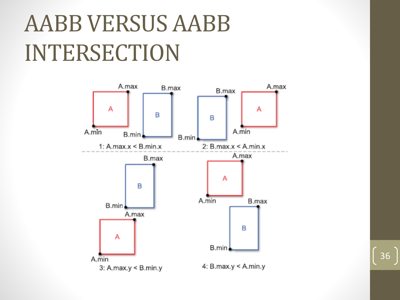




PERFORMING QUERY: 'What is Euler integration used for in game physics?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 9.62)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_1_Math_Physic.pdf, Page: 46 (Score: 17.5000)


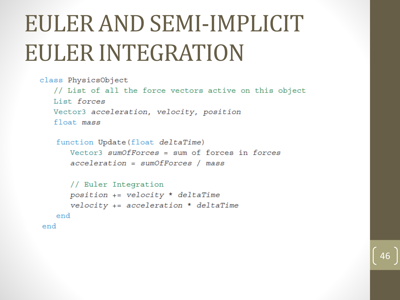

  Source: Chap_1_Math_Physic.pdf, Page: 47 (Score: 15.3125)


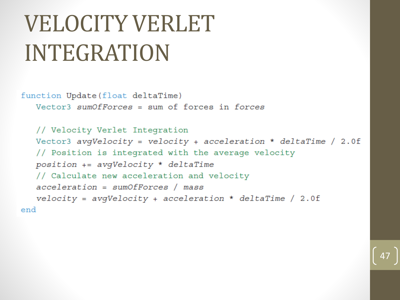

  Source: Chap_1_Math_Physic.pdf, Page: 49 (Score: 13.9375)


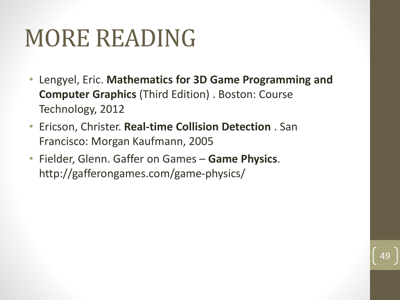




PERFORMING QUERY: 'How is the dot product used in collision detection?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 38 (Score: 7.82)
  Snippet: LINE SEGMENT VERSUS
TRIANGLE INTERSECTION

construct the plane for the triangle, calculate normal (n)

-> calculate v by construct 2 vectors from triangle

then cross product then normalize)

-> if they intersect, check if in/outside triangle by dot ...

  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 7.13)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap_1_Math_Physic.pdf, Page: 13 (Score: 5.70)
  Snippet: CROSS PRODUCT

Cross product (a), and right-hand rule (b)....


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_1_Math_Physic.pdf, Page: 34 (Score: 16.3750)


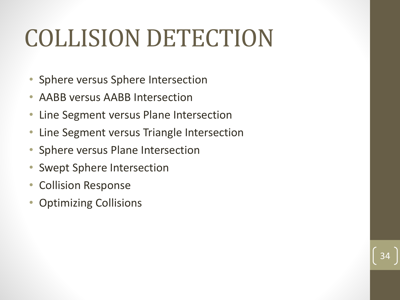

  Source: Chap_1_Math_Physic.pdf, Page: 32 (Score: 15.7500)


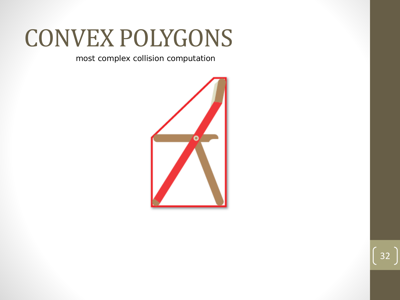

  Source: Chap_1_Math_Physic.pdf, Page: 2 (Score: 15.6250)


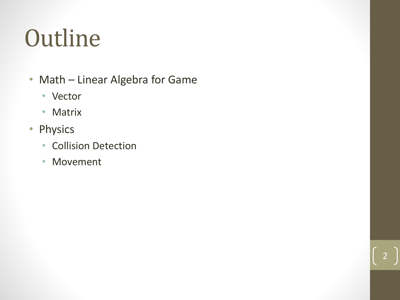




PERFORMING QUERY: 'What is swept sphere intersection?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap_1_Math_Physic.pdf, Page: 33 (Score: 5.50)
  Snippet: LIST OF COLLISION
GEOMETRIES

2??

human: sphere for head, aabb for torso, conext polygons for arms-legs...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_1_Math_Physic.pdf, Page: 40 (Score: 16.1250)


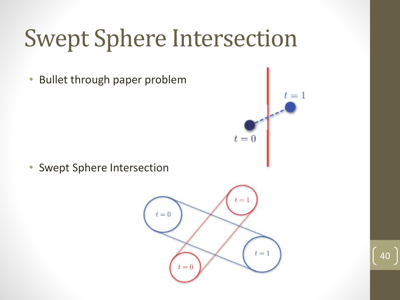

  Source: Chap_1_Math_Physic.pdf, Page: 34 (Score: 15.1250)


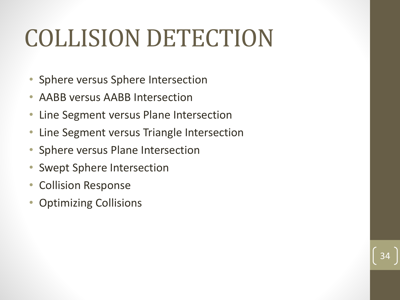

  Source: Chap_1_Math_Physic.pdf, Page: 35 (Score: 13.1875)


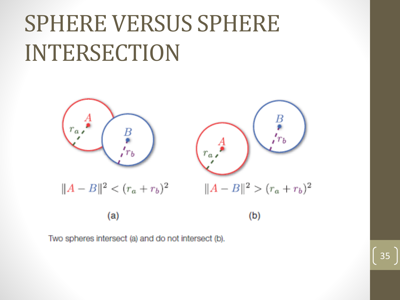




PERFORMING QUERY: 'What is a sprite sheet?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap_1_Math_Physic.pdf, Page: 23 (Score: 6.74)
  Snippet: TRANSPOSE

row major: each row is a vector
column major: each column is a vector (rhs)...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_2_2D_Graphics.pdf, Page: 10 (Score: 15.6250)


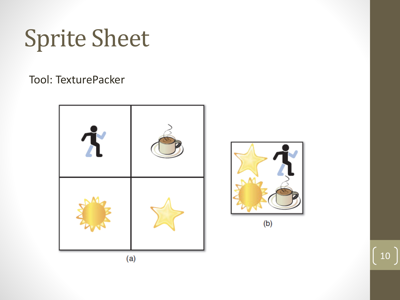

  Source: Chap_0_Introduction.pdf, Page: 12 (Score: 14.3125)


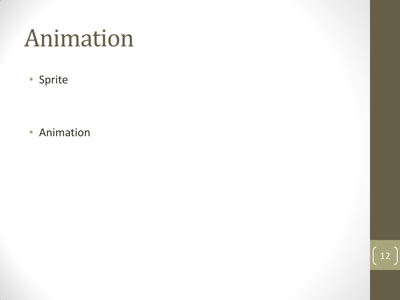

  Source: Chap_2_2D_Graphics.pdf, Page: 3 (Score: 13.9375)


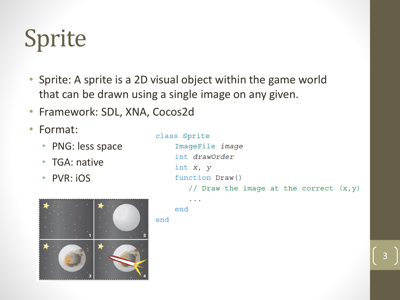




PERFORMING QUERY: 'What is parallax scrolling?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_2_2D_Graphics.pdf, Page: 16 (Score: 15.6250)


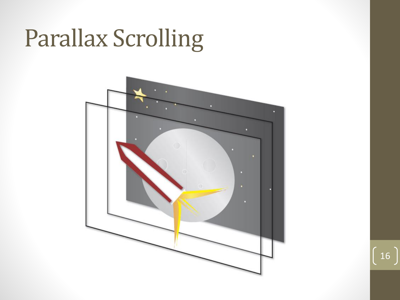

  Source: Chap_2_2D_Graphics.pdf, Page: 2 (Score: 12.2500)


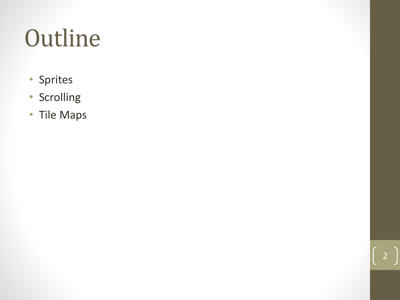

  Source: Chap_2_2D_Graphics.pdf, Page: 18 (Score: 12.1250)


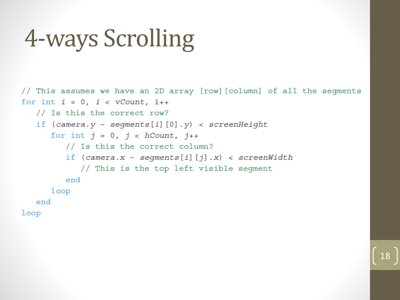




PERFORMING QUERY: 'What are tile maps used for?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 5.07)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 4.92)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_2_2D_Graphics.pdf, Page: 20 (Score: 16.2500)


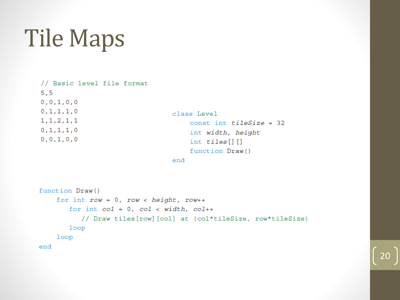

  Source: Chap_2_2D_Graphics.pdf, Page: 19 (Score: 15.8125)


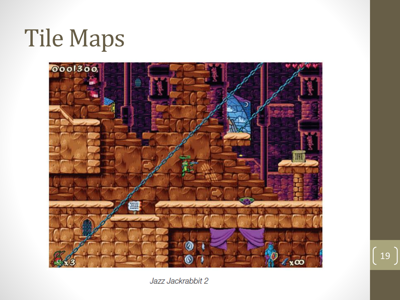

  Source: Chap_2_2D_Graphics.pdf, Page: 2 (Score: 15.4375)


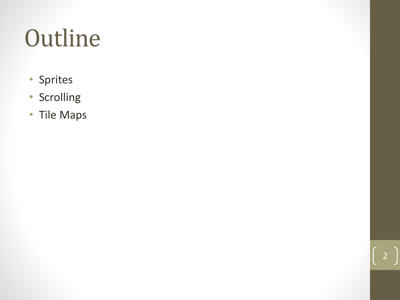




PERFORMING QUERY: 'What are the advantages of PNG and TGA image formats in 2D games?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 5 (Score: 7.70)
  Snippet: Improve the generate procedure so that only good
moves are generated.

Improve the test procedure so that the best moves
will be recognized and explored first....

  Source: Chap_2_2D_Graphics.pdf, Page: 3 (Score: 7.54)
  Snippet: Sprite

* Sprite: A sprite is a 2D visual object within the game world
that can be drawn using a single image on any given.

¢ Framework: SDL, XNA, Cocos2d
* Format:

class Sprite
PNG: less space ImageFile image
. int drawOrder
» TGA: native
int xX, ...

  Source: Chap4_AI_Minimax.pdf, Page: 6 (Score: 6.93)
  Snippet: Improve the generate procedure so that only good
moves are generated.

plausible-moves vs. legal-moves

Improve the test procedure so that the best moves
will be recognized and explored first.

less moves to be evaluated...


--- ✅ Results fr

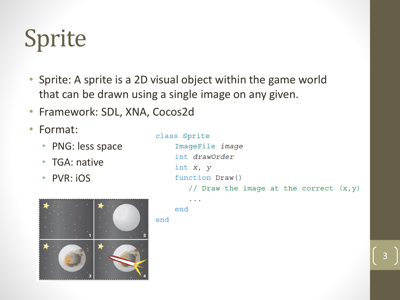

  Source: Chap_2_2D_Graphics.pdf, Page: 13 (Score: 16.7500)


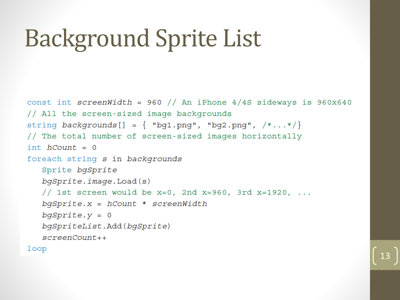

  Source: Chap_2_2D_Graphics.pdf, Page: 2 (Score: 15.2500)


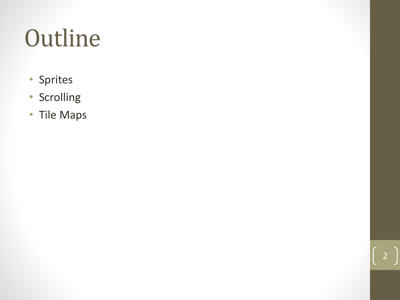




PERFORMING QUERY: 'What is the clamp algorithm in scrolling games?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap_1_Math_Physic.pdf, Page: 37 (Score: 5.65)
  Snippet: LINE SEGMENT VERSUS PLANE
INTERSECTION

R(t) = Ro + vt Find t so that R(t) is on the plane
0 (aka the time ray R pass the plane)
P-n+d=0

t must be in [0,1] range
t < 0 -> line segment face away from the plane

wy yy

v-n=O0

line segmet?) RO paralle...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_2_2D_Graphics.pdf, Page: 14 (Score: 15.2500)


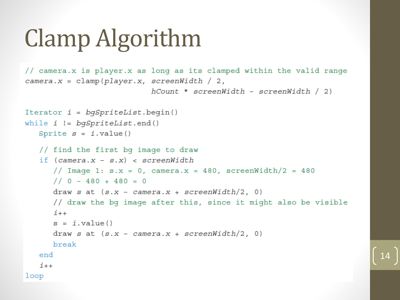

  Source: Chap_2_2D_Graphics.pdf, Page: 11 (Score: 13.4375)


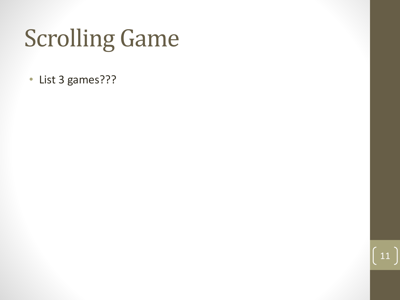

  Source: Chap_2_2D_Graphics.pdf, Page: 18 (Score: 12.9375)


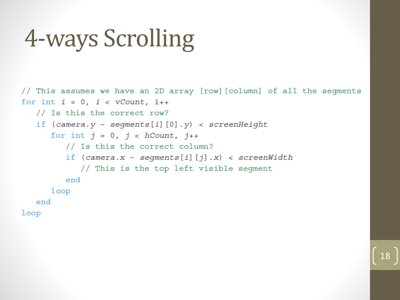




PERFORMING QUERY: 'What is the A* algorithm in game AI?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_3_AI.pdf, Page: 11 (Score: 16.7500)


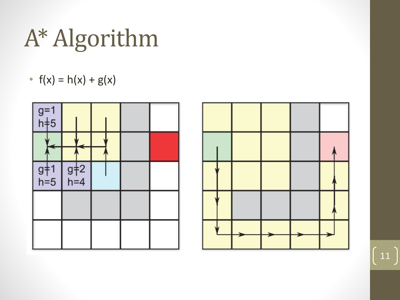

  Source: Chap_3_AI.pdf, Page: 2 (Score: 15.5625)


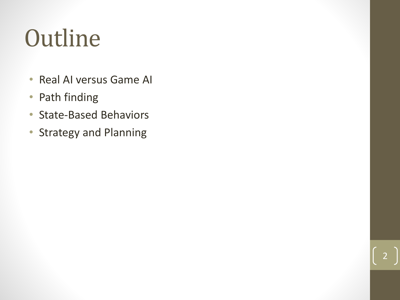

  Source: Chap_3_AI.pdf, Page: 15 (Score: 15.2500)


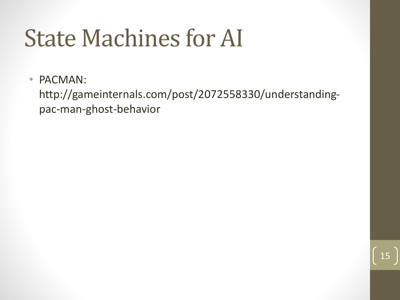




PERFORMING QUERY: 'What is Dijkstra’s algorithm used for?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 7.13)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap_3_AI.pdf, Page: 12 (Score: 7.09)
  Snippet: Dijkstra’s Algorithm

° f(x) = ???...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_3_AI.pdf, Page: 12 (Score: 19.1250)


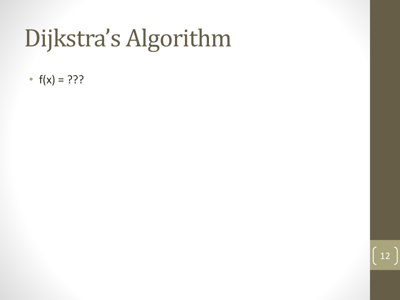

  Source: Chap_3_AI.pdf, Page: 11 (Score: 14.0000)


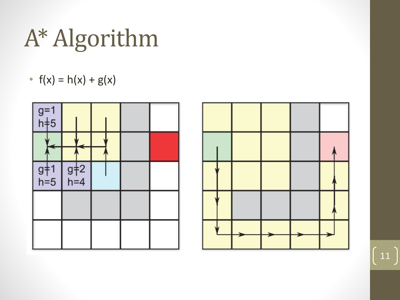

  Source: Chap4_AI_Minimax.pdf, Page: 16 (Score: 12.1875)


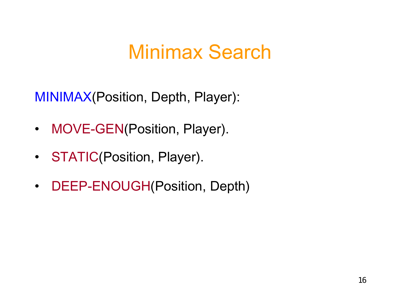




PERFORMING QUERY: 'What is a behavior tree in game AI?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_3_AI.pdf, Page: 20 (Score: 16.7500)


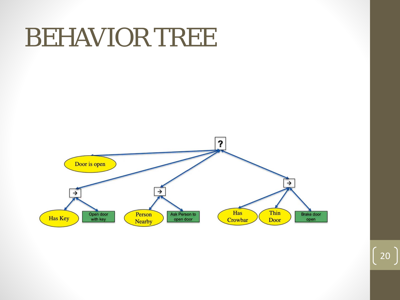

  Source: Chap_3_AI.pdf, Page: 19 (Score: 16.6250)


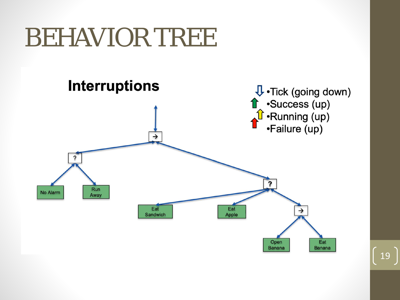

  Source: Chap_3_AI.pdf, Page: 18 (Score: 16.1250)


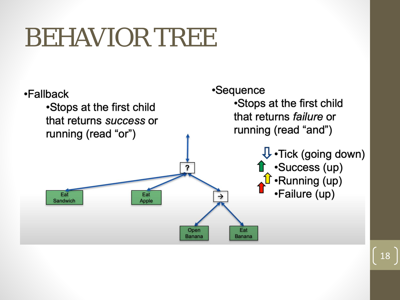




PERFORMING QUERY: 'What is the minimax algorithm?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap4_AI_Minimax.pdf, Page: 16 (Score: 16.1250)


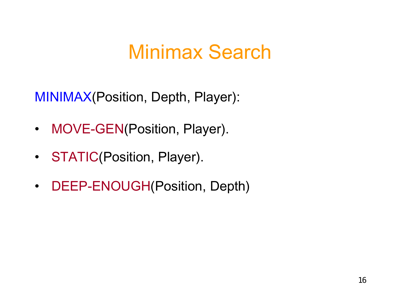

  Source: Chap4_AI_Minimax.pdf, Page: 10 (Score: 15.5000)


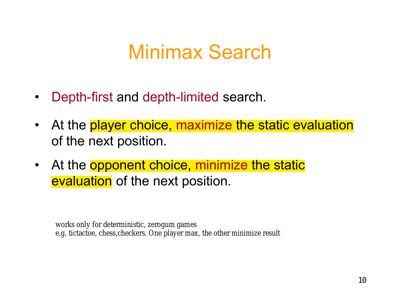

  Source: Chap4_AI_Minimax.pdf, Page: 14 (Score: 15.2500)


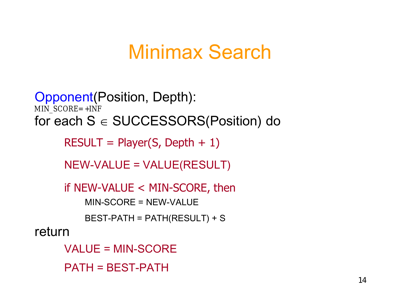




PERFORMING QUERY: 'What are alpha-beta cutoffs?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 2 (Score: 7.09)
  Snippet: Overview
Minimax search
Adding alpha-beta cutoffs

Additional refinements...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 4.92)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap4_AI_Minimax.pdf, Page: 24 (Score: 15.8125)


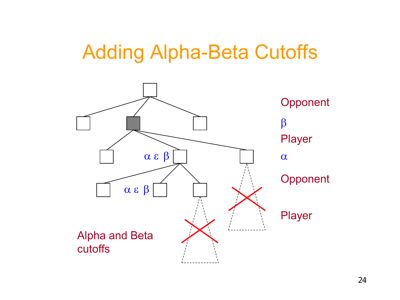

  Source: Chap4_AI_Minimax.pdf, Page: 22 (Score: 15.5625)


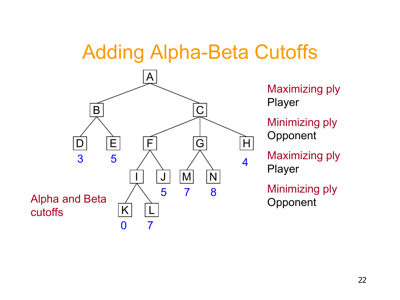

  Source: Chap4_AI_Minimax.pdf, Page: 23 (Score: 15.5625)


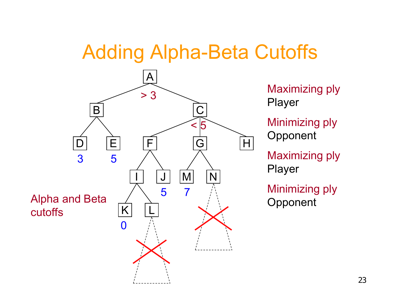




PERFORMING QUERY: 'What is client prediction in networked games?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_4_Network.pdf, Page: 10 (Score: 14.0625)


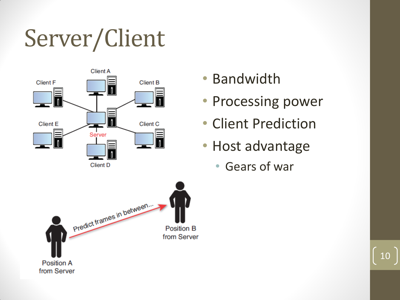

  Source: Chap_4_Network.pdf, Page: 1 (Score: 13.1250)


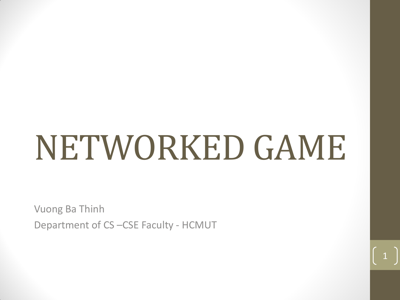

  Source: Chap4_AI_Minimax.pdf, Page: 1 (Score: 11.0000)


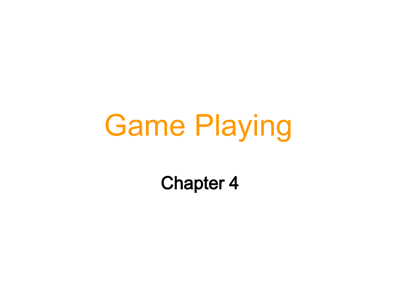




PERFORMING QUERY: 'What is the difference between TCP and UDP in games?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 10 (Score: 7.90)
  Snippet: DOT PRODUCT

(a) (b)

Angle between unit vectors (a), and scalar projection (b)....

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_4_Network.pdf, Page: 3 (Score: 7.09)
  Snippet: Protocol

- IP
* ICMP
* TCP
* UDP...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_4_Network.pdf, Page: 6 (Score: 14.2500)


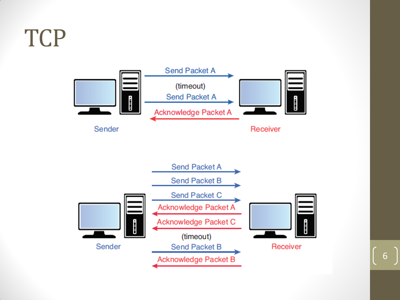

  Source: Chap_4_Network.pdf, Page: 1 (Score: 13.9375)


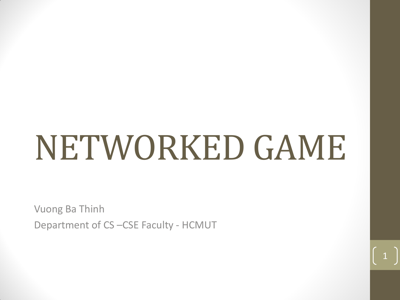

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 13.8750)


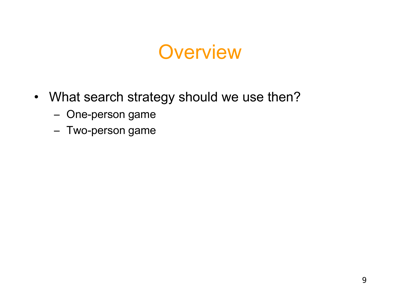




PERFORMING QUERY: 'What is peer-to-peer topology?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_4_Network.pdf, Page: 9 (Score: 16.7500)


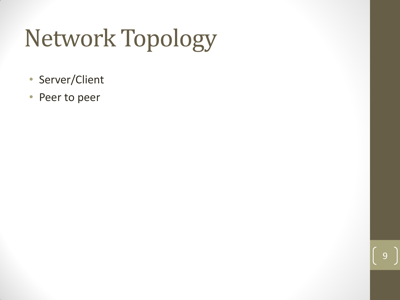

  Source: Chap_4_Network.pdf, Page: 11 (Score: 16.3750)


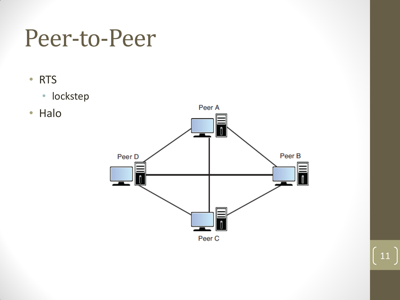

  Source: Chap_4_Network.pdf, Page: 2 (Score: 13.6875)


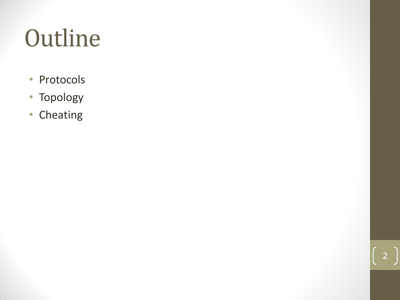




PERFORMING QUERY: 'What is cheating in online games?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_4_Network.pdf, Page: 12 (Score: 15.6875)


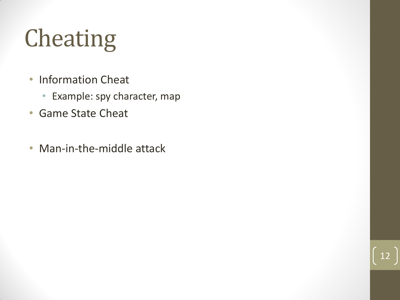

  Source: Chap_4_Network.pdf, Page: 2 (Score: 12.1250)


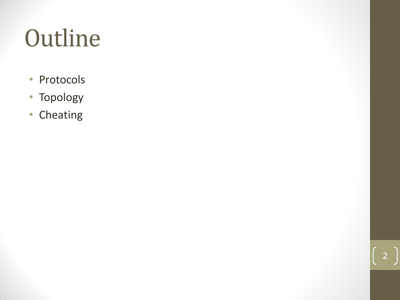

  Source: Chap4_AI_Minimax.pdf, Page: 3 (Score: 11.4375)


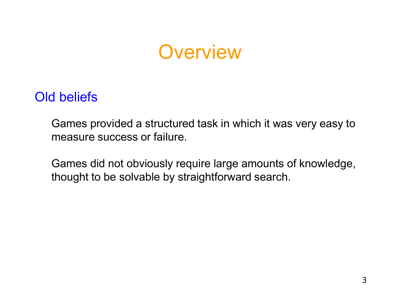




PERFORMING QUERY: 'What are homogeneous coordinates in 3D graphics?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 24 (Score: 5.05)
  Snippet: TRANSFORMING 3D VECTORS
BY MATRICES...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 4.92)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 17.7500)


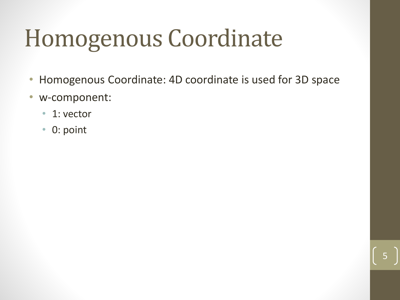

  Source: Chap_5_3D_Graphics.pdf, Page: 4 (Score: 13.8125)


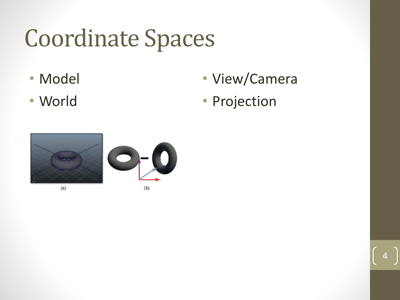

  Source: Chap_5_3D_Graphics.pdf, Page: 13 (Score: 13.2500)


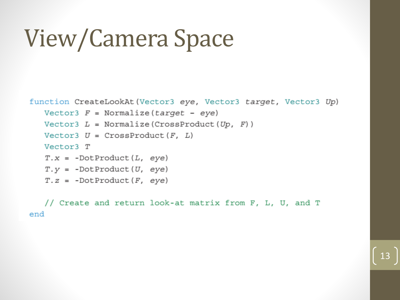




PERFORMING QUERY: 'What is the difference between orthographic and perspective projection?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 10 (Score: 7.90)
  Snippet: DOT PRODUCT

(a) (b)

Angle between unit vectors (a), and scalar projection (b)....

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 14 (Score: 19.3750)


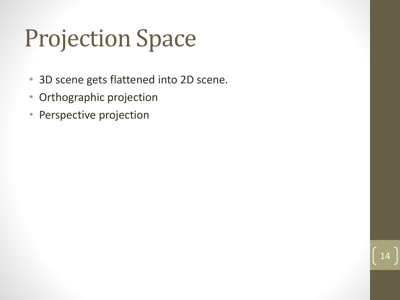

  Source: Chap_5_3D_Graphics.pdf, Page: 17 (Score: 18.8750)


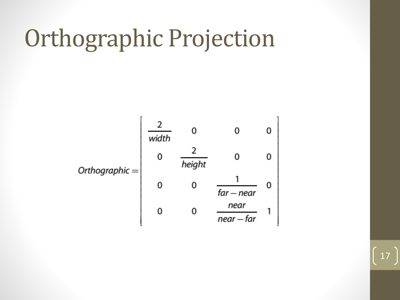

  Source: Chap_5_3D_Graphics.pdf, Page: 15 (Score: 18.7500)


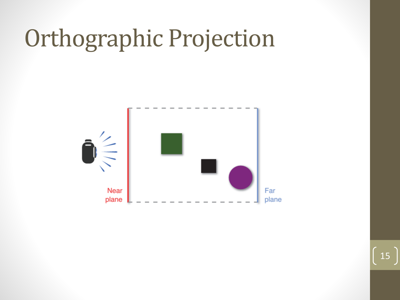




PERFORMING QUERY: 'What are quaternions used for in 3D graphics?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 11.05)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap_1_Math_Physic.pdf, Page: 24 (Score: 5.05)
  Snippet: TRANSFORMING 3D VECTORS
BY MATRICES...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 4.92)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 22 (Score: 19.3750)


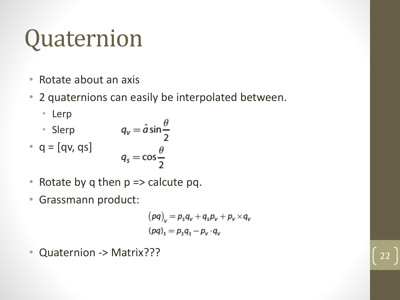

  Source: Chap_5_3D_Graphics.pdf, Page: 26 (Score: 16.0000)


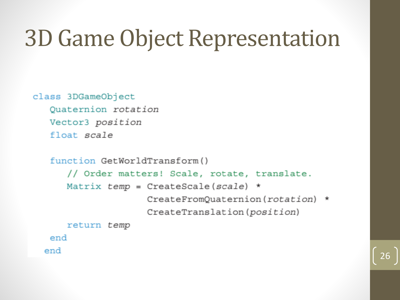

  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 12.8125)


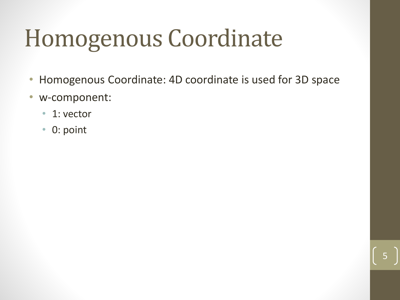




PERFORMING QUERY: 'What is Z-buffering?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 25 (Score: 16.0000)


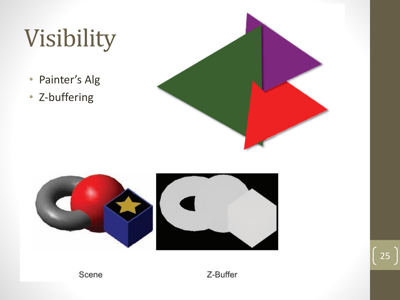

  Source: Chap_1_Math_Physic.pdf, Page: 29 (Score: 10.5000)


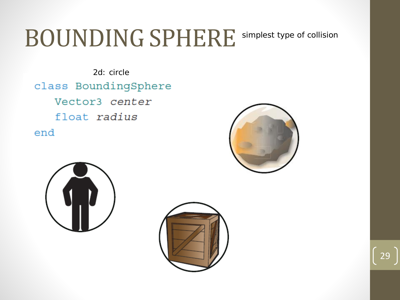

  Source: Chap_2_2D_Graphics.pdf, Page: 2 (Score: 10.1250)


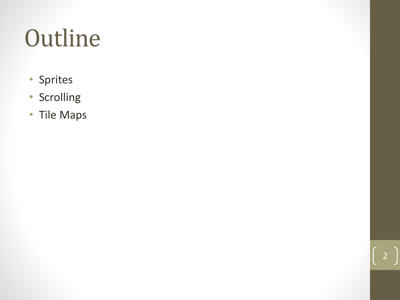




PERFORMING QUERY: 'What are transform matrices used for?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 5 (Score: 5.07)
  Snippet: Homogenous Coordinate

* Homogenous Coordinate: 4D coordinate is used for 3D space
* w-component:

« 1: vector

* OQ: point...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 4.92)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 4.64)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_5_3D_Graphics.pdf, Page: 7 (Score: 16.7500)


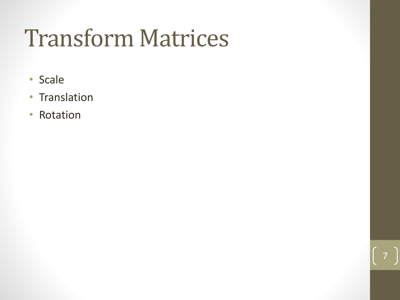

  Source: Chap_1_Math_Physic.pdf, Page: 24 (Score: 14.1250)


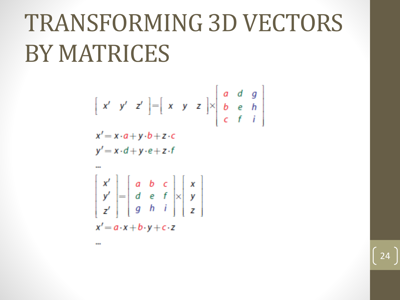

  Source: Chap_5_3D_Graphics.pdf, Page: 10 (Score: 12.7500)


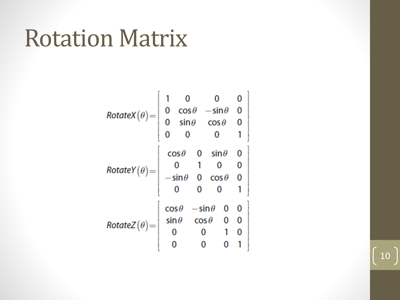




PERFORMING QUERY: 'What is the game loop?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_1_Math_Physic.pdf, Page: 28 (Score: 7.36)
  Snippet: COLLISION GEOMETRY

¢ What is it???
¢ Why do we use it?...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.93)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_0_Introduction.pdf, Page: 5 (Score: 16.1250)


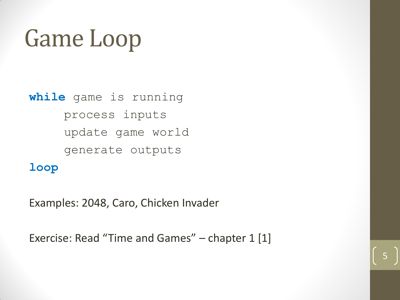

  Source: Chap_0_Introduction.pdf, Page: 2 (Score: 15.8125)


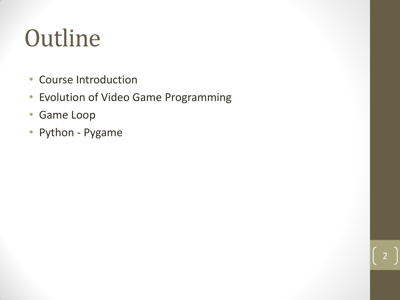

  Source: Chap_0_Introduction.pdf, Page: 8 (Score: 13.6875)


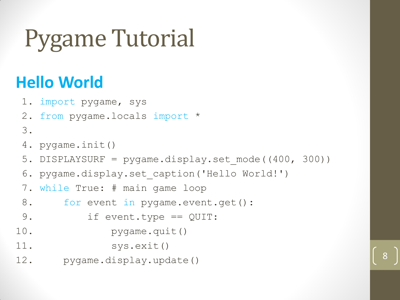




PERFORMING QUERY: 'What are the major eras of video game evolution?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 9 (Score: 8.97)
  Snippet: ¢ What search strategy should we use then?
  One-person game
  Two-person game...

  Source: Chap_0_Introduction.pdf, Page: 6 (Score: 6.65)
  Snippet: Game Objects

¢ What is Game Object?
* Types of Game Objects
* Draw-only
» Update-only
a,...

  Source: Chap4_AI_Minimax.pdf, Page: 5 (Score: 6.17)
  Snippet: Improve the generate procedure so that only good
moves are generated.

Improve the test procedure so that the best moves
will be recognized and explored first....


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_0_Introduction.pdf, Page: 4 (Score: 18.5000)


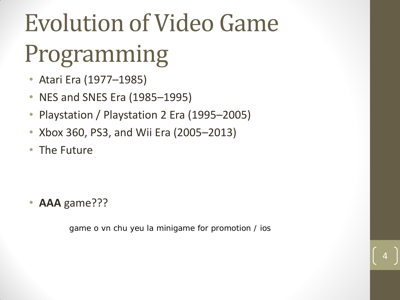

  Source: Chap_0_Introduction.pdf, Page: 2 (Score: 16.1250)


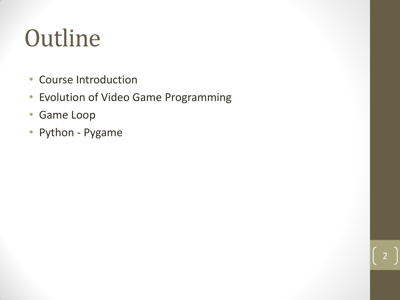

  Source: Chap4_AI_Minimax.pdf, Page: 3 (Score: 13.7500)


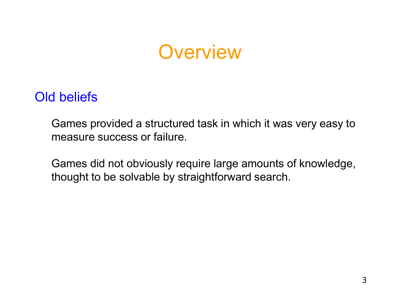




PERFORMING QUERY: 'What are sprites and why are they used?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap4_AI_Minimax.pdf, Page: 7 (Score: 8.13)
  Snippet: It is not usually possible to search until a goal state is
found.

It has to evaluate individual board positions by
estimating how likely they are to lead to a win.

Static evaluation function

Credit assignment problem (Minsky, 1963)....

  Source: Chap4_AI_Minimax.pdf, Page: 5 (Score: 8.10)
  Snippet: Improve the generate procedure so that only good
moves are generated.

Improve the test procedure so that the best moves
will be recognized and explored first....

  Source: Chap4_AI_Minimax.pdf, Page: 6 (Score: 7.16)
  Snippet: Improve the generate procedure so that only good
moves are generated.

plausible-moves vs. legal-moves

Improve the test procedure so that the best moves
will be recognized and explored first.

less moves to be evaluated...


--- ✅ Results from Pipeline B (ColQwen) ---
  Source: Chap_

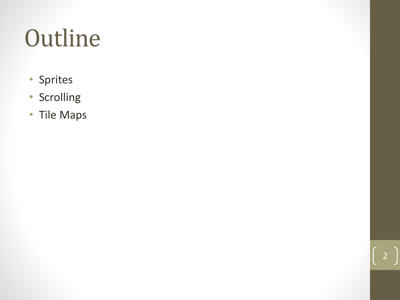

  Source: Chap_2_2D_Graphics.pdf, Page: 4 (Score: 14.5625)


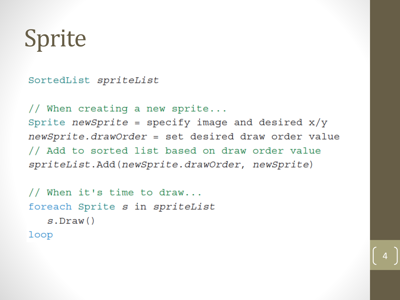

  Source: Chap_2_2D_Graphics.pdf, Page: 14 (Score: 14.1250)


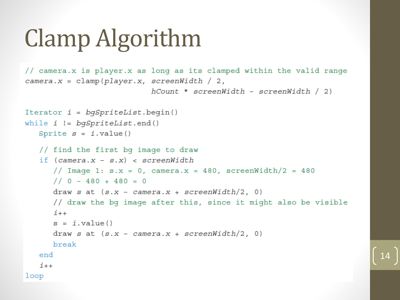




PERFORMING QUERY: 'How does pygame draw basic shapes?'

--- ✅ Results from Pipeline A (Your OCR + BM25) ---
  Source: Chap_0_Introduction.pdf, Page: 11 (Score: 6.59)
  Snippet: Drawing Introduction

pygame.draw.rect   draw a rectangle shape
pygame.draw.polygon   draw a shape with any number of sides

pygame.draw.circle   draw a circle around a point
pygame.draw.ellipse   draw a round shape inside a rectangle
pygame.draw.arc...

  Source: Chap_2_2D_Graphics.pdf, Page: 4 (Score: 4.11)
  Snippet: Sprite

SortedList spriteList

// When creating a new sprite...

Sprite newSprite = specify image and desired x/y
newSprite.drawOrder = set desired draw order value
// Add to sorted list based on draw order value
spriteList.Add(newSprite.drawOrder, n...

  Source: Chap_2_2D_Graphics.pdf, Page: 14 (Score: 1.37)
  Snippet: Clamp Algorithm

// camera.x is player.x as long as its clamped within the valid range
camera.x = clamp(player.x, screenWidth / 2,
hCount * screenWidth - screenWidth / 2)

Ite

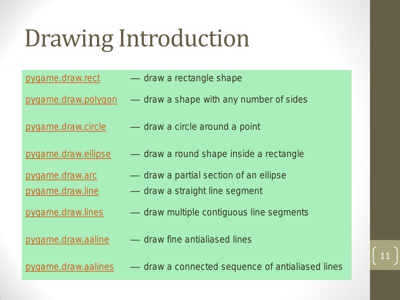

  Source: Chap_0_Introduction.pdf, Page: 8 (Score: 14.5000)


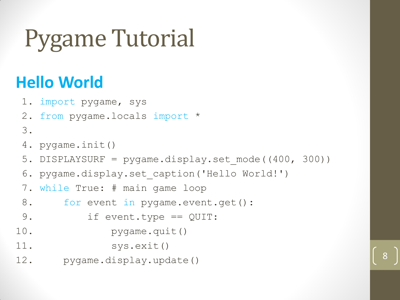

  Source: Chap_0_Introduction.pdf, Page: 2 (Score: 13.1875)


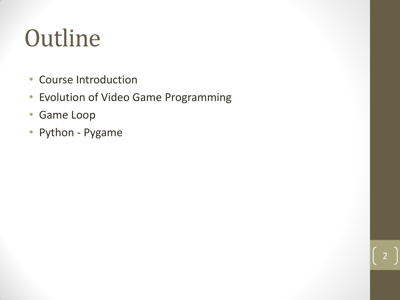

In [14]:
# --- 4. HEAD-TO-HEAD EVALUATION ---
from IPython.display import display

# print("--- RELOADING ColQwen FOR EVALUATION ---")
# # 1. Reload the core index data from disk
# SAVE_DIR = "results/colqwen_index"
# with open(os.path.join(SAVE_DIR, 'colqwen_index.pkl'), 'rb') as f:
#     colqwen_index = pickle.load(f)
# with open(os.path.join(SAVE_DIR, 'colqwen_images.pkl'), 'rb') as f:
#     colqwen_images = pickle.load(f)
# print("✅ ColQwen Index loaded from disk.")

# # 2. Reload the model and processor to run the search function
# import torch
# from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor
# device = "cuda" if torch.cuda.is_available() else "cpu"
# processor = ColQwen2_5_Processor.from_pretrained('vidore/colqwen2.5-v0.2')
# model = ColQwen2_5.from_pretrained(
#     'vidore/colqwen2.5-v0.2', 
#     torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
#     device_map=device,
# ).eval()
# print("✅ ColQwen Model re-loaded.")

# Define a set of diverse queries to test both systems
queries = [
    "What is the plane equation used in game physics?",
    "What is the difference between AABB and bounding sphere collision detection?",
    "What is Euler integration used for in game physics?",
    "How is the dot product used in collision detection?",
    "What is swept sphere intersection?",
    "What is a sprite sheet?",
    "What is parallax scrolling?",
    "What are tile maps used for?",
    "What are the advantages of PNG and TGA image formats in 2D games?",
    "What is the clamp algorithm in scrolling games?",
    "What is the A* algorithm in game AI?",
    "What is Dijkstra’s algorithm used for?",
    "What is a behavior tree in game AI?",
    "What is the minimax algorithm?",
    "What are alpha-beta cutoffs?",
    "What is client prediction in networked games?",
    "What is the difference between TCP and UDP in games?",
    "What is peer-to-peer topology?",
    "What is cheating in online games?",
    "What are homogeneous coordinates in 3D graphics?",
    "What is the difference between orthographic and perspective projection?",
    "What are quaternions used for in 3D graphics?",
    "What is Z-buffering?",
    "What are transform matrices used for?",
    "What is the game loop?",
    "What are the major eras of video game evolution?",
    "What are sprites and why are they used?",
    "How does pygame draw basic shapes?"
]


for query in queries:
    print("="*80)
    print(f"PERFORMING QUERY: '{query}'")
    print("="*80)
    
    # --- Pipeline A Results ---
    print("\n--- ✅ Results from Pipeline A (Your OCR + BM25) ---")
    ocr_search_results = search_ocr_pipeline(query)
    if not ocr_search_results:
        print("No results found.")
    for res in ocr_search_results:
        print(f"  Source: {res['source']}, Page: {res['page']} (Score: {res['score']:.2f})")
        print(f"  Snippet: {res['text_snippet']}\n")

    # --- Pipeline B Results ---
    print("\n--- ✅ Results from Pipeline B (ColQwen) ---")
    colqwen_search_results = search_colqwen_pipeline(query)
    if not colqwen_search_results:
        print("No results found.")
    for res in colqwen_search_results:
        print(f"  Source: {res['source']}, Page: {res['page']} (Score: {res['score']:.4f})")
        # Display the actual image result from ColQwen
        display(res['image'].resize((400, 300)))
    
    print("\n\n")